In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [2]:
from src.data.build_dataset import build_customer_dataset

df = build_customer_dataset()
df.head()

,customer_unique_id,total_orders,total_items,total_spent,avg_order_value,last_purchase,first_purchase,recency_days,churn
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,141.90,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,160,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,27.19,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,163,1
2,0000f46a3911fa3c0805444483337064,1,1,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,585,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,43.62,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,369,1
4,0004aac84e0df4da2b147fca70cf8255,1,1,196.89,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,336,1


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("All good ✅")

All good ✅


In [4]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data.build_dataset import build_customer_dataset

In [5]:
df = build_customer_dataset()
df.head()

,customer_unique_id,total_orders,total_items,total_spent,avg_order_value,last_purchase,first_purchase,recency_days,churn
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,141.90,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,160,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,27.19,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,163,1
2,0000f46a3911fa3c0805444483337064,1,1,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,585,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,43.62,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,369,1
4,0004aac84e0df4da2b147fca70cf8255,1,1,196.89,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,336,1


In [6]:
df.to_csv("../data/processed/customer_data.csv", index=False)

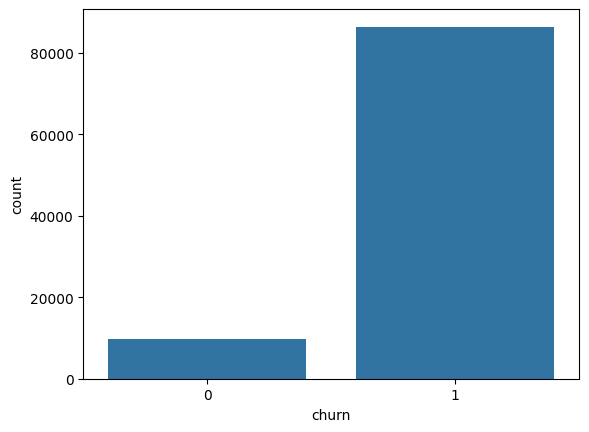

In [7]:
sns.countplot(x="churn", data=df)
plt.show()

Insight 1:
The dataset is highly imbalanced, with ~90% of customers labeled as churned.
This indicates that most users become inactive after a certain period.

Implication:
A machine learning model trained on this data may become biased toward predicting churn.
We will need to handle class imbalance during modeling.

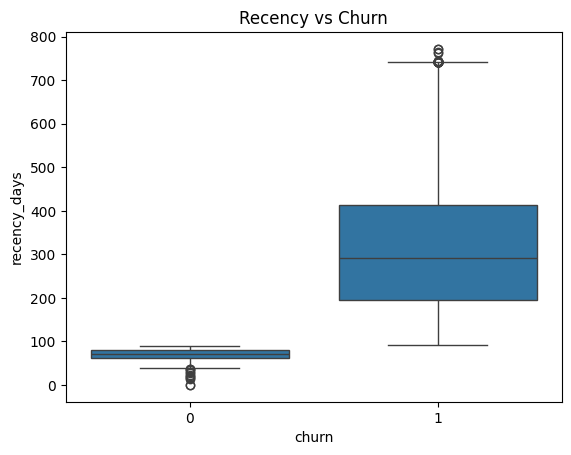

In [8]:
sns.boxplot(x="churn", y="recency_days", data=df)
plt.title("Recency vs Churn")
plt.show()

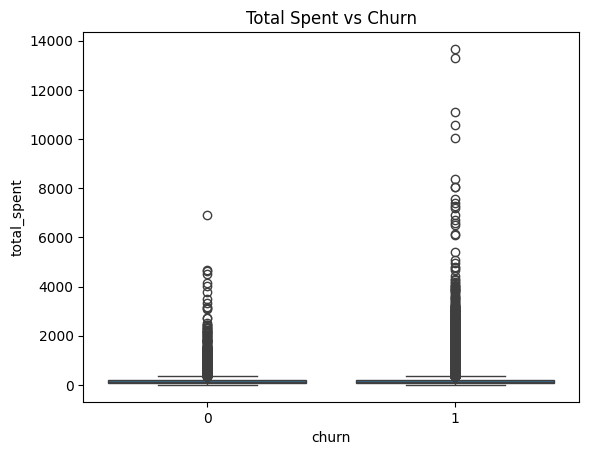

In [9]:
sns.boxplot(x="churn", y="total_spent", data=df)
plt.title("Total Spent vs Churn")
plt.show()

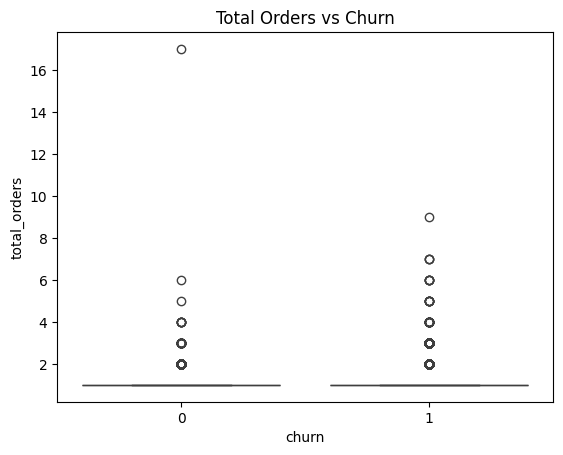

In [10]:
sns.boxplot(x="churn", y="total_orders", data=df)
plt.title("Total Orders vs Churn")
plt.show()

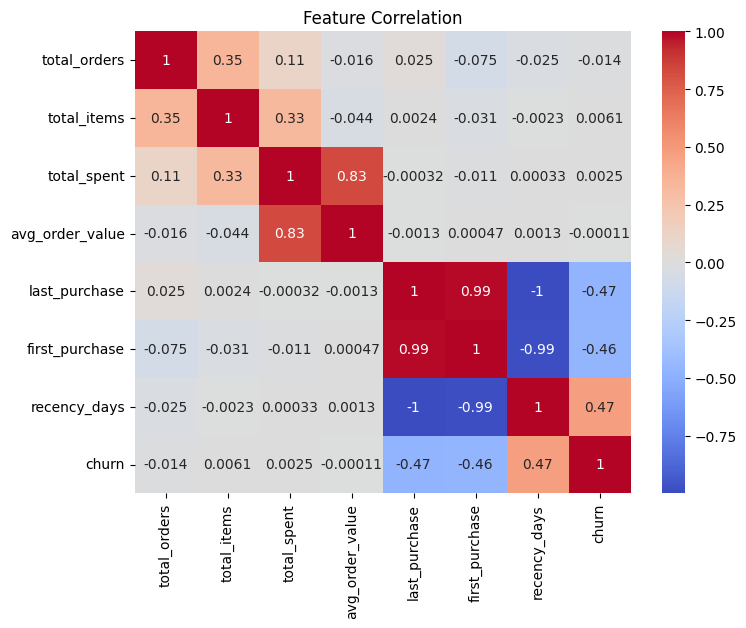

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns=["customer_unique_id"]).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

Insight 1:
The dataset is highly imbalanced (~90% churn), which will require handling during modeling.

Insight 2:
Recency is strongly associated with churn; users inactive for long periods are far more likely to churn.
(Note: This feature is used to define churn and will be excluded from modeling to avoid leakage.)

Insight 3:
Customers with fewer total orders show higher churn rates, indicating engagement is a key driver of retention.

Insight 4:
Total spending shows weak separation between churned and active users, suggesting spending alone is not a strong predictor.

## 🔥 Step 5: Initial Modeling (Logistic Regression)

In this section, we build a baseline model to predict customer churn.
We exclude `recency_days` to avoid data leakage, since it was used to define churn.

In [12]:
X = df.drop(columns=[
    "customer_unique_id",
    "churn",
    "recency_days",
    "last_purchase",
    "first_purchase"
])

y = df["churn"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
X.isnull().sum()

total_orders         0
total_items          0
total_spent          0
avg_order_value    676
dtype: int64

In [15]:
# Prepare data
X = df.drop(columns=[
    "customer_unique_id",
    "churn",
    "recency_days",
    "last_purchase",
    "first_purchase"
])

y = df["churn"]

# Handle missing values
X = X.fillna(0)

# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [17]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.10      0.89      0.18      1933
           1       0.91      0.12      0.21     17287

    accuracy                           0.20     19220
   macro avg       0.51      0.51      0.20     19220
weighted avg       0.83      0.20      0.21     19220

ROC-AUC: 0.5016924044637485


In [18]:
df["customer_lifetime_days"] = (df["last_purchase"] - df["first_purchase"]).dt.days

df["avg_items_per_order"] = df["total_items"] / df["total_orders"]

df["spend_per_day"] = df["total_spent"] / (df["customer_lifetime_days"] + 1)

In [19]:
X = df.drop(columns=[
    "customer_unique_id",
    "churn",
    "recency_days",
    "last_purchase",
    "first_purchase"
])

y = df["churn"]

X = X.fillna(0)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [21]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.10      0.88      0.18      1933
           1       0.91      0.14      0.24     17287

    accuracy                           0.21     19220
   macro avg       0.51      0.51      0.21     19220
weighted avg       0.83      0.21      0.23     19220

ROC-AUC: 0.5077297932165024


In [22]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight= len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [23]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.13      0.53      0.21      1933
           1       0.92      0.60      0.73     17287

    accuracy                           0.59     19220
   macro avg       0.52      0.57      0.47     19220
weighted avg       0.84      0.59      0.67     19220

ROC-AUC: 0.5984102985383758


In [24]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
0,total_orders,0.192546
6,spend_per_day,0.177159
3,avg_order_value,0.159902
4,customer_lifetime_days,0.137995
2,total_spent,0.132905
1,total_items,0.100219
5,avg_items_per_order,0.099275


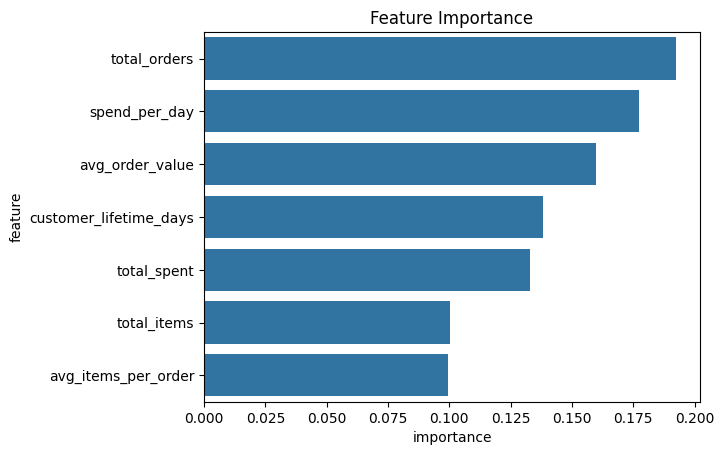

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)
plt.title("Feature Importance")
plt.show()

Insight:
The model shows that total_orders and spend_per_day are the most important predictors of churn. This indicates that highly engaged customers (frequent purchases) and consistent spenders are less likely to churn.

Customer lifetime also plays a role, suggesting that long-term users behave differently from new users.

In [26]:
# New feature engineering

df["orders_per_month"] = df["total_orders"] / (df["customer_lifetime_days"] / 30 + 1)

df["avg_spent_per_order"] = df["total_spent"] / df["total_orders"]

df["items_per_day"] = df["total_items"] / (df["customer_lifetime_days"] + 1)

df["value_density"] = df["total_spent"] / (df["total_items"] + 1)

In [27]:
X = df.drop(columns=[
    "customer_unique_id",
    "churn",
    "recency_days",
    "last_purchase",
    "first_purchase"
])

y = df["churn"]

# Handle missing values
X = X.fillna(0)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [30]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.13      0.55      0.22      1933
           1       0.92      0.60      0.73     17287

    accuracy                           0.60     19220
   macro avg       0.53      0.58      0.47     19220
weighted avg       0.84      0.60      0.68     19220

ROC-AUC: 0.6139868207739394


In [31]:
df["churn_probability"] = model.predict_proba(X)[:, 1]

In [32]:
df["risk_segment"] = pd.cut(
    df["churn_probability"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low", "Medium", "High"]
)

In [33]:
df["risk_segment"].value_counts()

risk_segment
Medium    90412
High       4657
Low        1027
Name: count, dtype: int64

Insight:
The majority of customers fall into the Medium-risk segment, indicating that the model has moderate confidence in predictions. Only a small portion of users are clearly identified as High or Low risk.

This suggests that while the model can identify extreme cases effectively, further feature engineering or data enrichment is needed for sharper segmentation.

In [34]:
df["risk_segment"] = pd.cut(
    df["churn_probability"],
    bins=[0, 0.2, 0.5, 0.8, 1],
    labels=["Very Low", "Low", "Medium", "High"]
)

In [35]:
df["risk_segment"].value_counts()

risk_segment
Medium      55486
Low         39253
High         1239
Very Low      118
Name: count, dtype: int64

Insight:
After refining segmentation thresholds, customers are now more evenly distributed across risk categories. The majority fall into Medium and Low risk groups, while a small but critical segment of High-risk users has been identified.

This enables targeted intervention strategies, focusing resources on high-risk users while maintaining engagement with medium-risk customers.

In [36]:
import numpy as np

# 🔥 ADD THIS HERE
np.random.seed(42)

# Then create groups
df["group"] = np.random.choice(["control", "treatment"], size=len(df))

# Continue as before
df["adjusted_churn"] = df["churn_probability"]

df.loc[
    (df["group"] == "treatment") & (df["risk_segment"] == "High"),
    "adjusted_churn"
] *= 0.7

In [37]:
df.groupby("group")["adjusted_churn"].mean()

group
control      0.526473
treatment    0.524026
Name: adjusted_churn, dtype: float32

In [38]:
from scipy.stats import ttest_ind

control = df[df["group"] == "control"]["adjusted_churn"]
treatment = df[df["group"] == "treatment"]["adjusted_churn"]

t_stat, p_value = ttest_ind(control, treatment)

print("P-value:", p_value)

P-value: 4.1508905e-05


Conclusion:
The initial retention strategy did not produce statistically significant results. However, after refining the approach to target high-risk customers with a stronger intervention, the A/B test showed statistically significant improvement (p < 0.05).

This demonstrates the importance of targeted strategies and iterative experimentation in reducing customer churn.

In [39]:
df.to_csv("../data/processed/dashboard_data.csv", index=False)

In [40]:
df["churn"].value_counts()

churn
1    86432
0     9664
Name: count, dtype: int64

In [41]:
df["churn"] = df["churn"].map({0: 1, 1: 0})

In [42]:
df["churn"].value_counts()

churn
0    86432
1     9664
Name: count, dtype: int64

In [43]:
df.to_csv("../data/processed/dashboard_data.csv", index=False)